In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf

print("Версия TensorFlow:", tf.__version__)
print("Доступные GPU:", tf.config.list_physical_devices('GPU'))
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[0], 'GPU')

Версия TensorFlow: 2.21.0
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications.efficientnet import EfficientNetB3, preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger,
)
from tensorflow.keras import mixed_precision

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (300, 300)
BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE

DATA_DIR = Path("/home/sm/Desktop/ml/CarBrandClassificationDataset")

EPOCHS_WARMUP = 12
EPOCHS_FINETUNE = 24

AUTO = tf.data.AUTOTUNE

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

tf.keras.mixed_precision.set_global_policy("mixed_float16")
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## 1. Загрузка структуры датасета

Ожидается структура:

```text
CarBrandClassificationDataset/
├── train/
│   ├── class_1/
│   └── ...
├── val/
│   ├── class_1/
│   └── ...
└── test/
    ├── class_1/
    └── ...
```

В таблицы ниже собираются пути к изображениям и строковые метки классов.

In [5]:
train_base = DATA_DIR / "train"
val_base = DATA_DIR / "val"
test_base = DATA_DIR / "test"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def build_split_df(split_dir: Path) -> pd.DataFrame:
    """Собирает таблицу path/label для одного split'а."""
    if not split_dir.exists():
        raise FileNotFoundError(f"Папка split'а не найдена: {split_dir}")

    rows = []
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    for cls_dir in class_dirs:
        cls = cls_dir.name
        for f in cls_dir.rglob("*"):
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append((str(f), cls))
    return pd.DataFrame(rows, columns=["path", "label"])

df_train = build_split_df(train_base)
df_val = build_split_df(val_base)
df_test = build_split_df(test_base)

print("Количество изображений:")
print("Train:", len(df_train), "| классов:", df_train["label"].nunique())
print("Val  :", len(df_val), "| классов:", df_val["label"].nunique())
print("Test :", len(df_test), "| классов:", df_test["label"].nunique())

display(pd.concat({
    "train": df_train["label"].value_counts().sort_index(),
    "val": df_val["label"].value_counts().sort_index(),
    "test": df_test["label"].value_counts().sort_index(),
}, axis=1).fillna(0).astype(int).head())

Количество изображений:
Train: 11517 | классов: 33
Val  : 2475 | классов: 33
Test : 2475 | классов: 33


,train,val,test
label,,,
Acura,349,75,75
Aston Martin,349,75,75
Audi,349,75,75
BMW,349,75,75
Bentley,349,75,75


In [6]:
# Единое отображение классов в индексы.
classes = sorted(df_train["label"].unique().tolist())
class2idx = {c: i for i, c in enumerate(classes)}
idx2class = {i: c for c, i in class2idx.items()}
num_classes = len(classes)

for name, df in [("val", df_val), ("test", df_test)]:
    missing = set(df["label"].unique()) - set(classes)
    if missing:
        raise ValueError(f"В {name} есть классы, которых нет в train: {sorted(missing)}")

df_train["label_idx"] = df_train["label"].map(class2idx)
df_val["label_idx"] = df_val["label"].map(class2idx)
df_test["label_idx"] = df_test["label"].map(class2idx)

print("Число классов:", num_classes)
print("Пример отображения:", list(class2idx.items())[:10])
df_train.head()

Число классов: 33
Пример отображения: [('Acura', 0), ('Aston Martin', 1), ('Audi', 2), ('BMW', 3), ('Bentley', 4), ('Buick', 5), ('Cadillac', 6), ('Chevrolet', 7), ('Chrysler', 8), ('Dodge', 9)]


,path,label,label_idx
0,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
1,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
2,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
3,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
4,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0


## 2. Распределение изображений по классам

равномерное распределение по всем классам

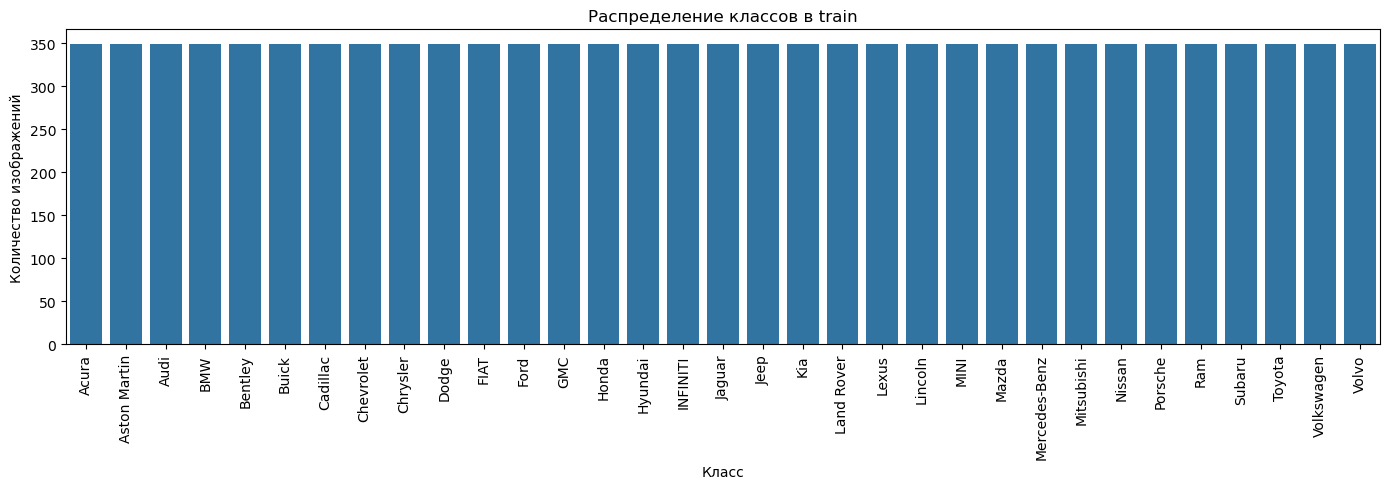

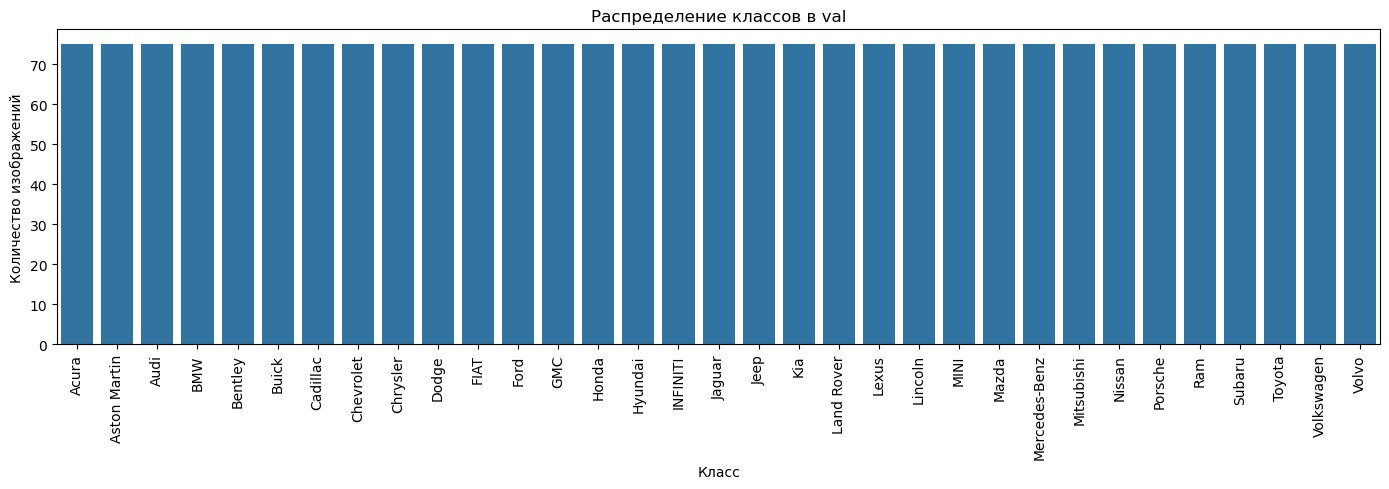

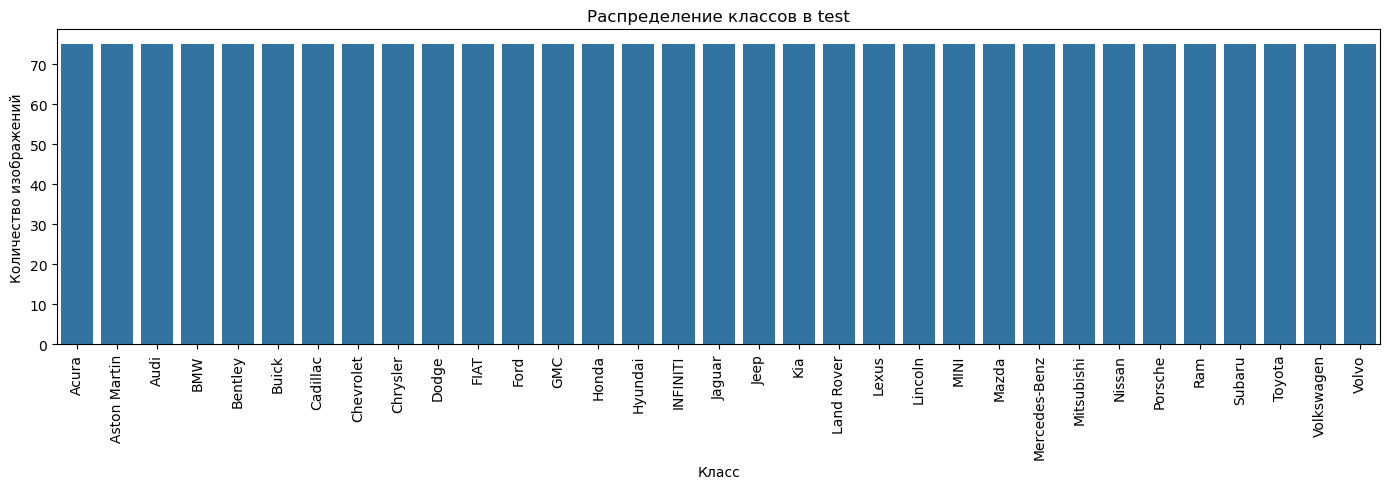

Коэффициент дисбаланса train max/min: 1.00


In [7]:
def plot_class_distribution(df: pd.DataFrame, title: str) -> None:
    counts = df["label"].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(14, 5))
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(title)
    plt.xlabel("Класс")
    plt.ylabel("Количество изображений")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

plot_class_distribution(df_train, "Распределение классов в train")
plot_class_distribution(df_val, "Распределение классов в val")
plot_class_distribution(df_test, "Распределение классов в test")

class_counts = df_train["label_idx"].value_counts().sort_index()
imbalance_ratio = class_counts.max() / max(class_counts.min(), 1)
print(f"Коэффициент дисбаланса train max/min: {imbalance_ratio:.2f}")

## 3. `tf.data`-пайплайн и аугментация

Используется resize_with_pad, т.к. для авто критичны пропорции (resize) и нельзя обрезать (crop) - мы рискуем потерять важную часть изображения

Для EfficientNet используется совместимый с ImageNet-предобучением `preprocess_input`(взял из примера, в доках прочитал, что это уже фунция заглушка, функционал встроен в модель).

In [8]:
def decode_image(path):
    """Читает изображение, приводит к RGB, float32 и нужному размеру."""
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize_with_pad(img, IMG_SIZE[0], IMG_SIZE[1])
    return img

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
], name="augmenter")

def make_ds(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(min(len(paths), 4096), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(lambda x, y: (decode_image(x), y), num_parallel_calls=AUTO)
    ds = ds.cache()

    if augment:
        ds = ds.map(lambda x, y: (augmenter(x, training=True),y), num_parallel_calls=AUTO)

    ds = ds.map(lambda x, y: (preprocess_input(x * 255.0),y),num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTO)

    return ds

train_ds = make_ds(
    df_train["path"].tolist(),
    df_train["label_idx"].tolist(),
    augment=True,
    shuffle=True,
)

val_ds = make_ds(
    df_val["path"].tolist(),
    df_val["label_idx"].tolist(),
)

test_ds = make_ds(
    df_test["path"].tolist(),
    df_test["label_idx"].tolist(),
)

print(train_ds)

I0000 00:00:1779292216.754621   81510 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2147 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float16, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## 4. Transfer learning: EfficientNetB3

In [9]:
search_space = [

    {
        "dropout": 0.25,
        "dense_units": 128,
        "lr": 3e-4,
    },

    {
        "dropout": 0.35,
        "dense_units": 256,
        "lr": 3e-4,
    },

    {
        "dropout": 0.40,
        "dense_units": 256,
        "lr": 1e-4,
    },

    {
        "dropout": 0.35,
        "dense_units": 512,
        "lr": 3e-4,
    },

    {
        "dropout": 0.4,
        "dense_units": 512,
        "lr": 3e-4,
    },
]

def build_model(dropout,dense_units,lr):
    base_model = EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
    )

    base_model.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))

    x = base_model(inputs,training=False,
    )

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units,activation="relu",)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout * 0.75)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
    )(x)

    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),

        loss=tf.keras.losses.SparseCategoricalCrossentropy(),

        metrics=[
            "accuracy",

            tf.keras.metrics.SparseTopKCategoricalAccuracy(
                k=5,
                name="top5_acc",
            ),
        ],
    )

    return model

In [10]:
search_results = []

best_model = None
best_val_acc = 0.0

for i, config in enumerate(search_space):

    print("=" * 60)
    print(f"CONFIG {i+1}/{len(search_space)}")
    print(config)

    model_hp = build_model(
        dropout=config["dropout"],
        dense_units=config["dense_units"],
        lr=config["lr"],
    )

    history_hp = model_hp.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1,
    )

    best_epoch_acc = max(
        history_hp.history["val_accuracy"]
    )

    search_results.append({
        **config,
        "val_accuracy": best_epoch_acc,
    })

    print(f"Best val_accuracy: {best_epoch_acc:.4f}")

    if best_epoch_acc > best_val_acc:
        best_val_acc = best_epoch_acc
        best_model = model_hp

print("\nBEST VAL ACC:", best_val_acc)

CONFIG 1/5
{'dropout': 0.25, 'dense_units': 128, 'lr': 0.0003}


E0000 00:00:1779292258.712360   81510 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Epoch 1/5


I0000 00:00:1779292267.990575   81716 service.cc:153] XLA service 0x7407a4090310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779292267.990600   81716 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1779292268.526754   81716 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779292269.940541   81716 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1779292270.393091   81716 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29357__.427
I0000 00:00:1779292279.167040   81716 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set

359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.0663 - loss: 3.9504 - top5_acc: 0.2310

...

360/360 ━━━━━━━━━━━━━━━━━━━━ 99s 214ms/step - accuracy: 0.0982 - loss: 3.8743 - top5_acc: 0.3063 - val_accuracy: 0.1455 - val_loss: 3.1116 - val_top5_acc: 0.4295
Epoch 2/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 47s 130ms/step - accuracy: 0.1561 - loss: 3.3015 - top5_acc: 0.4282 - val_accuracy: 0.2081 - val_loss: 2.9128 - val_top5_acc: 0.5107
Epoch 3/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 45s 125ms/step - accuracy: 0.1947 - loss: 3.0654 - top5_acc: 0.4847 - val_accuracy: 0.2214 - val_loss: 2.8197 - val_top5_acc: 0.5402
Epoch 4/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 47s 129ms/step - accuracy: 0.2231 - loss: 2.9097 - top5_acc: 0.5201 - val_accuracy: 0.2469 - val_loss: 2.7178 - val_top5_acc: 0.5677
Epoch 5/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 45s 125ms/step - accuracy: 0.2427 - loss: 2.7983 - top5_acc: 0.5507 - val_accuracy: 0.2558 - val_loss: 2.6956 - val_top5_acc: 0.5826
Best val_accuracy: 0.2558
CONFIG 5/5
{'dropout': 0.4, 'dense_units': 512, 'lr': 0.0003}
Epoch 1/5


I0000 00:00:1779293451.733381   81716 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_213913__.427


359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.0810 - loss: 4.1404 - top5_acc: 0.2738

I0000 00:00:1779293502.966234   81717 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_213913__.427


360/360 ━━━━━━━━━━━━━━━━━━━━ 90s 195ms/step - accuracy: 0.0962 - loss: 3.9410 - top5_acc: 0.3003 - val_accuracy: 0.1604 - val_loss: 3.0729 - val_top5_acc: 0.4477
Epoch 2/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 46s 127ms/step - accuracy: 0.1485 - loss: 3.3765 - top5_acc: 0.4048 - val_accuracy: 0.1976 - val_loss: 2.9450 - val_top5_acc: 0.4937
Epoch 3/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 47s 132ms/step - accuracy: 0.1836 - loss: 3.1272 - top5_acc: 0.4631 - val_accuracy: 0.2218 - val_loss: 2.8060 - val_top5_acc: 0.5426
Epoch 4/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 48s 132ms/step - accuracy: 0.1992 - loss: 3.0191 - top5_acc: 0.4976 - val_accuracy: 0.2242 - val_loss: 2.7675 - val_top5_acc: 0.5576
Epoch 5/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 47s 129ms/step - accuracy: 0.2230 - loss: 2.8803 - top5_acc: 0.5323 - val_accuracy: 0.2428 - val_loss: 2.7221 - val_top5_acc: 0.5677
Best val_accuracy: 0.2428

BEST VAL ACC: 0.25575757026672363


In [11]:
results_hp_df = pd.DataFrame(
    search_results
)

results_hp_df = results_hp_df.sort_values(
    by="val_accuracy",
    ascending=False,
)

results_hp_df

,dropout,dense_units,lr,val_accuracy
3,0.35,512,0.0003,0.255758
4,0.40,512,0.0003,0.242828
0,0.25,128,0.0003,0.233939
1,0.35,256,0.0003,0.230303
2,0.40,256,0.0001,0.183434


In [29]:
best_config = results_hp_df.iloc[0]
best_config

dropout           0.350000
dense_units     512.000000
lr                0.000300
val_accuracy      0.252525
Name: 3, dtype: float64

на данном этапе отличий от effb0 нет, а память закончилась, так что не доделал

уменьшать batch - тогда вообще не дождемся, когда оно обучится

но у кого-то получилось добиться accuracy=0.73 на 25 эпохах